In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=5)
        probs = tf.reduce_sum(y_pred * y_true_oh, axis=-1)
        focal_weight = alpha * tf.pow(1.0 - probs, gamma)
        loss = -focal_weight * tf.math.log(probs + 1e-8)
        return tf.reduce_mean(loss)
    return loss_fn

X_test = np.load('data/X_test.npy')
y_test  = np.load('data/y_test.npy')
model   = keras.models.load_model(
    'models/cnn1d_final.keras',
    custom_objects={'loss_fn': focal_loss()}
)

class_names = ['N Normal', 'S Supra', 'V Ventricular', 'F Fusion', 'Q Unknown']
print(" Model loaded.")

 Model loaded.


In [7]:
y_proba = model.predict(X_test, batch_size=256)
y_pred  = np.argmax(y_proba, axis=1)
print("Predictions done.")

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Predictions done.


In [8]:
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

               precision    recall  f1-score   support

     N Normal     0.9831    0.9908    0.9869     18118
      S Supra     0.7603    0.6277    0.6877       556
V Ventricular     0.9524    0.9268    0.9394      1448
     F Fusion     0.7545    0.7778    0.7660       162
    Q Unknown     0.9862    0.9789    0.9825      1608

     accuracy                         0.9749     21892
    macro avg     0.8873    0.8604    0.8725     21892
 weighted avg     0.9739    0.9749    0.9742     21892



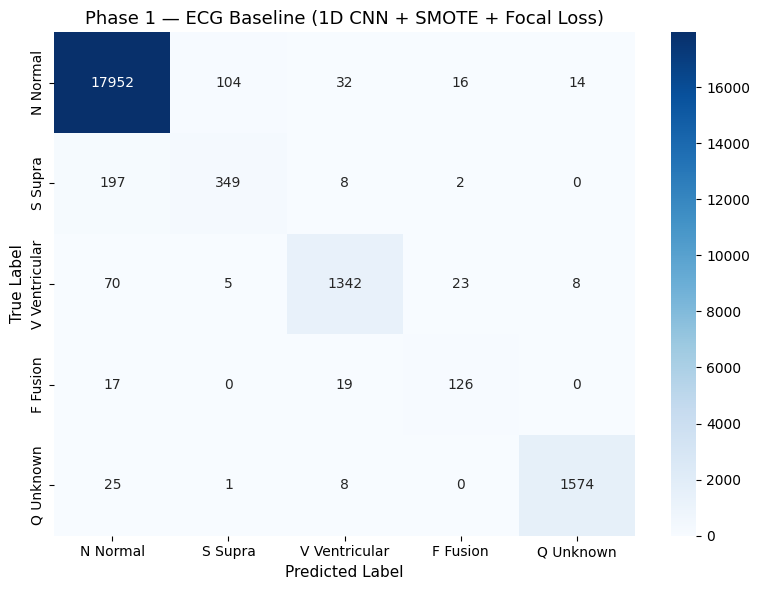

Saved → models/phase1_confusion_matrix.png


In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Phase 1 — ECG Baseline (1D CNN + SMOTE + Focal Loss)', fontsize=13)
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('models/phase1_confusion_matrix.png', dpi=200)
plt.show()
print("Saved → models/phase1_confusion_matrix.png")

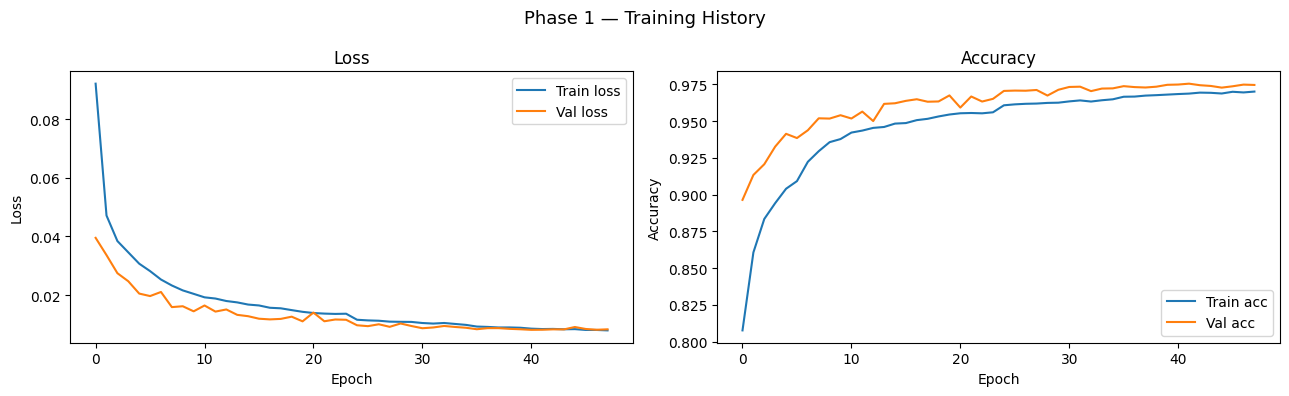

Saved → models/phase1_training_curves.png


In [10]:
history = np.load('models/history_final.npy', allow_pickle=True).item()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history['loss'],     label='Train loss', linewidth=1.5)
ax1.plot(history['val_loss'], label='Val loss',   linewidth=1.5)
ax1.set_title('Loss', fontsize=12)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history['accuracy'],     label='Train acc', linewidth=1.5)
ax2.plot(history['val_accuracy'], label='Val acc',   linewidth=1.5)
ax2.set_title('Accuracy', fontsize=12)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Phase 1 — Training History', fontsize=13)
plt.tight_layout()
plt.savefig('models/phase1_training_curves.png', dpi=200)
plt.show()
print("Saved → models/phase1_training_curves.png")

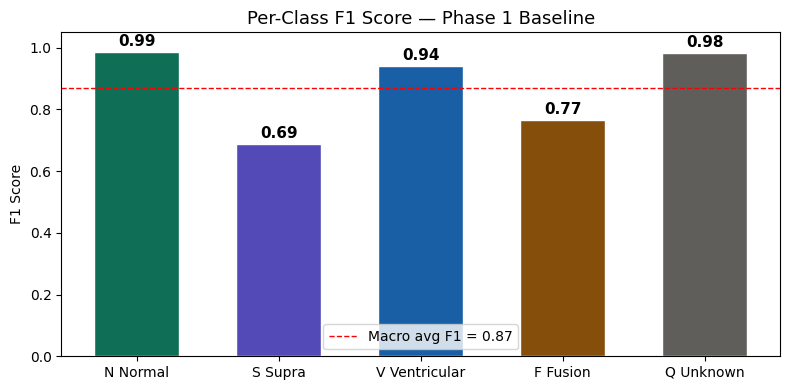

Saved → models/phase1_f1_bars.png


In [11]:
from sklearn.metrics import f1_score

f1_scores = f1_score(y_test, y_pred, average=None)
colors = ['#0F6E56', '#534AB7', '#185FA5', '#854F0B', '#5F5E5A']

plt.figure(figsize=(8, 4))
bars = plt.bar(class_names, f1_scores, color=colors, edgecolor='white', width=0.6)
plt.ylim(0, 1.05)
plt.axhline(y=0.87, color='red', linestyle='--', linewidth=1, label='Macro avg F1 = 0.87')
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('Per-Class F1 Score — Phase 1 Baseline', fontsize=13)
plt.ylabel('F1 Score')
plt.legend()
plt.tight_layout()
plt.savefig('models/phase1_f1_bars.png', dpi=200)
plt.show()
print("Saved → models/phase1_f1_bars.png")

In [12]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
mac = f1_score(y_test, y_pred, average='macro')
f1s = f1_score(y_test, y_pred, average=None)

print("=" * 45)
print("  PHASE 1 FINAL RESULTS — ECG BASELINE")
print("=" * 45)
print(f"  Overall accuracy : {acc*100:.2f}%")
print(f"  Macro F1         : {mac:.4f}")
print("-" * 45)
for name, score in zip(class_names, f1s):
    bar = '█' * int(score * 20)
    print(f"  {name:<18} F1 = {score:.4f}  {bar}")
print("=" * 45)
print(f"\nModel : models/cnn1d_phase1_final.keras")
print(f"Params: 57,189  |  Size: ~223 KB (pre-quantization)")
print(f"Target after INT8 quantization: ≤ 150 KB")

  PHASE 1 FINAL RESULTS — ECG BASELINE
  Overall accuracy : 97.49%
  Macro F1         : 0.8725
---------------------------------------------
  N Normal           F1 = 0.9869  ███████████████████
  S Supra            F1 = 0.6877  █████████████
  V Ventricular      F1 = 0.9394  ██████████████████
  F Fusion           F1 = 0.7660  ███████████████
  Q Unknown          F1 = 0.9825  ███████████████████

Model : models/cnn1d_phase1_final.keras
Params: 57,189  |  Size: ~223 KB (pre-quantization)
Target after INT8 quantization: ≤ 150 KB


In [13]:
import os

print("=== Phase 1 Checkpoint ===")
print("\nModels folder:")
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"  {f:<45} {size:.1f} KB")

print("\nData folder:")
for f in sorted(os.listdir('data')):
    size = os.path.getsize(f'data/{f}') / (1024*1024)
    print(f"  {f:<30} {size:.1f} MB")

=== Phase 1 Checkpoint ===

Models folder:
  cnn1d_final.keras                             728.3 KB
  cnn1d_improved.h5                             730.5 KB
  cnn1d_mitbih.h5                               730.5 KB
  confusion_matrix.png                          64.5 KB
  confusion_matrix_final.png                    61.7 KB
  confusion_matrix_improved.png                 62.3 KB
  history.npy                                   1.0 KB
  history_final.npy                             2.5 KB
  history_improved.npy                          2.5 KB
  phase1_confusion_matrix.png                   95.3 KB
  phase1_f1_bars.png                            51.8 KB
  phase1_training_curves.png                    111.3 KB
  training_curves.png                           71.3 KB
  training_curves_final.png                     68.6 KB
  y_pred_final.npy                              171.2 KB
  y_proba_final.npy                             427.7 KB

Data folder:
  X_test.npy                     15.6 MB
  X

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score
from sklearn.preprocessing import label_binarize
import os
os.makedirs('figures', exist_ok=True)

# Charger depuis le disque — pas besoin de réentraîner
y_test = np.load('data/y_test.npy')
y_pred_baseline = np.load('models/y_pred_final.npy')
y_proba_baseline = np.load('models/y_proba_final.npy')

print("Loaded. Shapes:")
print(f"  y_test: {y_test.shape}")
print(f"  y_pred: {y_pred_baseline.shape}")
print(f"  y_proba: {y_proba_baseline.shape}")

Loaded. Shapes:
  y_test: (21892,)
  y_pred: (21892,)
  y_proba: (21892, 5)


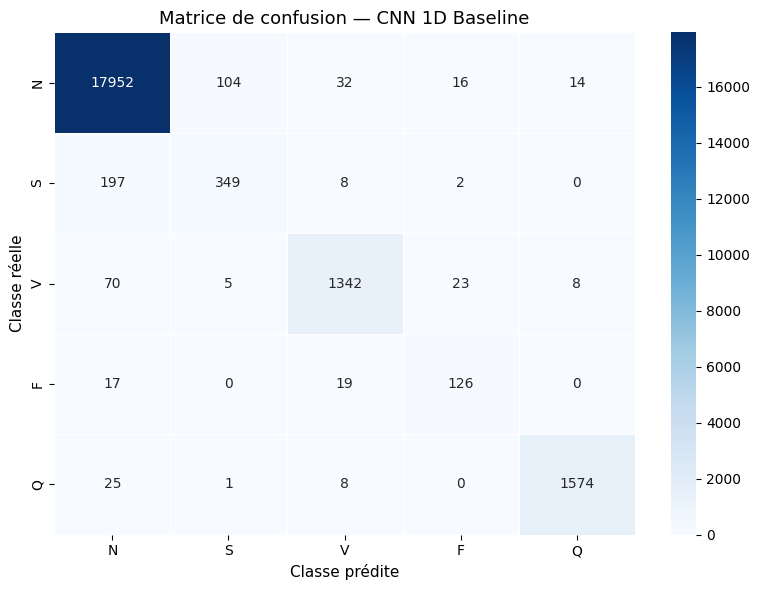

Saved confusion_baseline.png


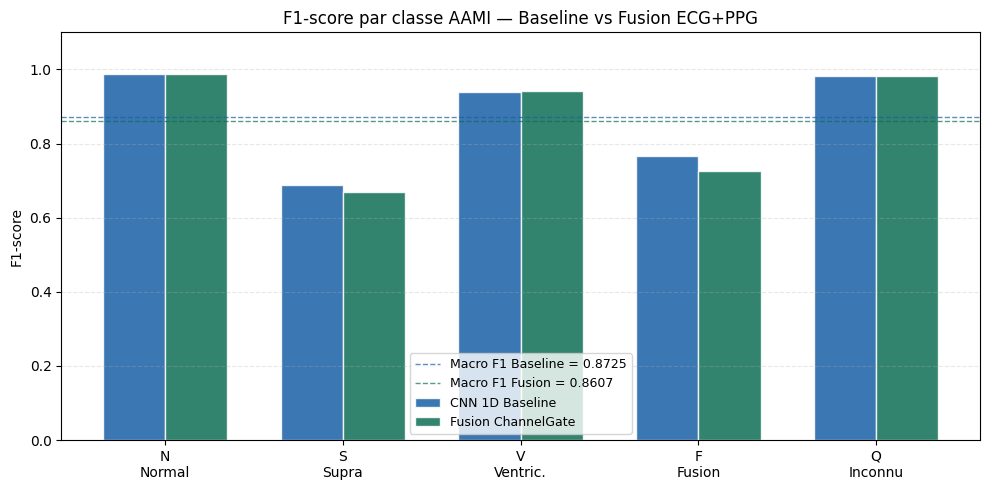

Saved f1_comparison.png


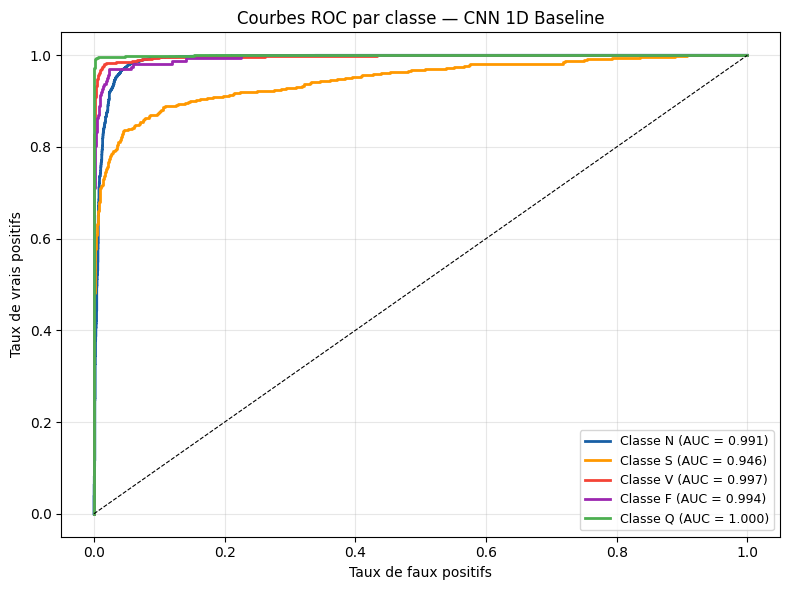

Saved roc_baseline.png


: 

In [ ]:
import os
os.makedirs('figures', exist_ok=True)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

class_names_short = ['N', 'S', 'V', 'F', 'Q']
class_names_full = ['N Normal', 'S Supra', 'V Ventricular', 'F Fusion', 'Q Unknown']

# Charger les prédictions sauvegardées
y_pred_baseline = np.load('models/y_pred_final.npy')
y_proba_baseline = np.load('models/y_proba_final.npy')
y_test = np.load('data/y_test.npy')

# ── Fig 4.1 : Matrice de confusion baseline ──────────────────────────────────
cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_short,
            yticklabels=class_names_short,
            linewidths=0.5)
plt.title('Matrice de confusion — CNN 1D Baseline', fontsize=13)
plt.ylabel('Classe réelle', fontsize=11)
plt.xlabel('Classe prédite', fontsize=11)
plt.tight_layout()
plt.savefig('figures/confusion_baseline.png', dpi=150)
plt.show()
print("Saved confusion_baseline.png")

# ── Fig 4.2 : F1 par classe — comparaison baseline vs fusion ─────────────────
from sklearn.metrics import f1_score
f1_baseline = f1_score(y_test, y_pred_baseline, average=None)

# F1 fusion depuis les résultats connus
f1_fusion = np.array([0.9870, 0.6689, 0.9414, 0.7246, 0.9815])

x = np.arange(5)
width = 0.35
colors_b = '#185FA5'
colors_f = '#0F6E56'

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, f1_baseline, width, label='CNN 1D Baseline',
               color=colors_b, alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, f1_fusion, width, label='Fusion ChannelGate',
               color=colors_f, alpha=0.85, edgecolor='white')

ax.axhline(y=0.8725, color=colors_b, linestyle='--', linewidth=1, alpha=0.7,
           label=f'Macro F1 Baseline = 0.8725')
ax.axhline(y=0.8607, color=colors_f, linestyle='--', linewidth=1, alpha=0.7,
           label=f'Macro F1 Fusion = 0.8607')

ax.set_xticks(x)
ax.set_xticklabels(['N\nNormal', 'S\nSupra', 'V\nVentric.', 'F\nFusion', 'Q\nInconnu'])
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.1)
ax.set_title('F1-score par classe AAMI — Baseline vs Fusion ECG+PPG')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/f1_comparison.png', dpi=150)
plt.show()
print("Saved f1_comparison.png")

# ── Fig 4.3 : Courbes ROC baseline ───────────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
colors_roc = ['#185FA5','#FF9800','#F44336','#9C27B0','#4CAF50']

plt.figure(figsize=(8, 6))
for i, (cls, col) in enumerate(zip(class_names_short, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_baseline[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=col, linewidth=2,
             label=f'Classe {cls} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC par classe — CNN 1D Baseline')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/roc_baseline.png', dpi=150)
plt.show()
print("Saved roc_baseline.png")